# CICIoT2023 — Standard GNN Baseline Study
**Baseline models evaluated (all under identical experimental conditions):**

1. **GCN** — Graph Convolutional Network (Kipf & Welling)
2. **GNN** — a generic, hand-written message-passing GNN (unnormalized mean aggregation)
3. **GraphSAGE** — inductive neighbourhood-sampling/aggregation GNN
4. **PINN** — a *constraint-informed* GNN (see Section 17 markdown for an honest discussion of
   why a conventional physics-informed neural network does not apply to this dataset)
5. **GIN** — Graph Isomorphism Network
6. **GAT** — Graph Attention Network

## 2. Environment Setup

We check for `torch` and `torch_geometric`. Kaggle GPU notebooks normally ship with PyTorch
pre-installed; PyTorch Geometric is installed on demand if missing. Modern PyG versions
(>= 2.3) ship pure-PyTorch implementations of `GCNConv`, `SAGEConv`, `GATConv`, `GINConv` and
`MessagePassing`, so the extra `torch-scatter` / `torch-sparse` compiled packages are **not**
required for this baseline notebook.


In [71]:
import sys
import subprocess

def pip_install(pkg):
    """Install a package quietly if it is not already importable."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import torch
except ImportError as e:
    raise RuntimeError(
        "PyTorch is not available in this environment. On Kaggle, enable a GPU-accelerated "
        "Python notebook, which ships with PyTorch pre-installed."
    ) from e

try:
    import torch_geometric  # noqa: F401
    print(f"torch_geometric already available: version {torch_geometric.__version__}")
except ImportError:
    print("torch_geometric not found -> installing (CPU/GPU-agnostic pip wheel) ...")
    pip_install("torch_geometric")
    import torch_geometric
    print(f"torch_geometric installed: version {torch_geometric.__version__}")

print(f"torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


torch_geometric already available: version 2.8.0.post1
torch version: 2.5.1+cu124
CUDA available: True


## 3. Import Libraries

In [72]:
import os
import re
import json
import time
import glob
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GINConv, MessagePassing

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
print("Libraries imported successfully.")


Libraries imported successfully.


## 4. Reproducibility Configuration



In [73]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Deterministic cuDNN behaviour where practical (may slightly reduce throughput).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

CONFIG = {
    # reproducibility
    "seed": SEED,

    # dataset subsetting (see Section 5/6 markdown for justification)
    "rows_per_file_cap": 10000,      # max rows read from each individual CICIoT2023 CSV file
    "max_total_rows": 30000,        # hard cap on total dataset size fed into graph construction
    "min_class_samples": 15,        # classes with fewer rows than this are dropped (documented)

    # split ratios (stratified)
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,

    # graph construction
    "k_neighbors": 5,               # k for the feature-similarity k-NN graph (see Section 12)

    # model architecture (IDENTICAL for every baseline model)
    "hidden_dim": 64,
    "num_layers": 2,
    "dropout": 0.3,
    "gat_heads": 4,

    # training (IDENTICAL for every baseline model)
    "learning_rate": 1e-3,
    "epochs": 50,
    "optimizer": "Adam",
    "weight_decay": 0.0,

    # PINN / constraint-informed model only
    "lambda_constraint": 0.1,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))
    total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"GPU total memory: {total_mem_gb:.2f} GB")
else:
    print("No GPU detected -> running on CPU. Training will be slower but the pipeline is "
          "identical; only wall-clock time differs.")

print("\n=== CONFIG ===")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Device: cuda
GPU name: Tesla T4
GPU total memory: 14.56 GB

=== CONFIG ===
  seed: 42
  rows_per_file_cap: 10000
  max_total_rows: 30000
  min_class_samples: 15
  train_ratio: 0.7
  val_ratio: 0.15
  test_ratio: 0.15
  k_neighbors: 5
  hidden_dim: 64
  num_layers: 2
  dropout: 0.3
  gat_heads: 4
  learning_rate: 0.001
  epochs: 50
  optimizer: Adam
  weight_decay: 0.0
  lambda_constraint: 0.1


## 5. Dataset Discovery



In [74]:
INPUT_ROOT = "/kaggle/input"

def discover_csv_files(root: str = INPUT_ROOT):
    """Recursively find every CSV file under `root`. Returns a sorted list of paths."""
    if not os.path.isdir(root):
        raise FileNotFoundError(
            f"'{root}' does not exist. This notebook is designed to run on Kaggle, where "
            f"attached datasets are mounted under /kaggle/input/. Please attach the CICIoT2023 "
            f"dataset to this notebook."
        )
    csv_paths = sorted(glob.glob(os.path.join(root, "**", "*.csv"), recursive=True))
    return csv_paths

csv_files = discover_csv_files()

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV files were found under /kaggle/input/. Please attach the CICIoT2023 dataset "
        "to this Kaggle notebook (Add Data -> search 'CICIoT2023') before running this cell."
    )

print(f"Discovered {len(csv_files)} CSV file(s) under {INPUT_ROOT}\n")

file_info = []
for p in csv_files:
    size_mb = os.path.getsize(p) / (1024 ** 2)
    file_info.append({"path": p, "size_mb": round(size_mb, 2)})

file_info_df = pd.DataFrame(file_info).sort_values("path").reset_index(drop=True)
total_size_gb = file_info_df["size_mb"].sum() / 1024
print(f"Total combined size on disk: {total_size_gb:.2f} GB")
display_cols = file_info_df.head(20)
print(f"\nShowing first {len(display_cols)} of {len(file_info_df)} files:")
display_cols


Discovered 3 CSV file(s) under /kaggle/input

Total combined size on disk: 2.16 GB

Showing first 3 of 3 files:


,path,size_mb
0,/kaggle/input/ciciot2023/CICIOT23/test/test.csv,331.84
1,/kaggle/input/ciciot2023/CICIOT23/train/train.csv,1548.24
2,/kaggle/input/ciciot2023/CICIOT23/validation/v...,331.80


## 6. Dataset Inspection




In [75]:
def count_csv_rows(path: str) -> int:
    """Count data rows (excluding header) via a fast single pass over the file."""
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        n = sum(1 for _ in f)
    return max(n - 1, 0)  # subtract header row


def sample_csv_file(path: str, cap: int, seed: int) -> pd.DataFrame:
    """Read a reproducible, randomly-positioned contiguous block of up to `cap` rows."""
    n_rows = count_csv_rows(path)
    if n_rows <= cap:
        return pd.read_csv(path)

    rng = np.random.RandomState(seed + abs(hash(os.path.basename(path))) % (2**31))
    max_start = n_rows - cap
    start = int(rng.randint(0, max_start + 1))
    # skiprows uses 1-based data-row indices; row 0 is the header and must always be kept
    skip = range(1, start + 1)
    df = pd.read_csv(path, skiprows=skip, nrows=cap)
    return df


print("Sampling each discovered CSV file (this may take a few minutes for many/large files)...\n")
per_file_frames = []
for i, path in enumerate(csv_files, start=1):
    df_i = sample_csv_file(path, CONFIG["rows_per_file_cap"], SEED)
    per_file_frames.append(df_i)
    if i <= 10 or i == len(csv_files):
        print(f"  [{i}/{len(csv_files)}] {os.path.basename(path)} -> sampled {len(df_i)} rows")
    elif i == 11:
        print("  ... (further per-file logs suppressed for brevity) ...")

df_raw = pd.concat(per_file_frames, ignore_index=True)
print(f"\nCombined (pre-cap) dataset shape: {df_raw.shape}")


Sampling each discovered CSV file (this may take a few minutes for many/large files)...

  [1/3] test.csv -> sampled 10000 rows
  [2/3] train.csv -> sampled 10000 rows
  [3/3] validation.csv -> sampled 10000 rows

Combined (pre-cap) dataset shape: (30000, 47)


In [76]:
# --- Basic structural inspection, BEFORE any cleaning/encoding decisions ---
print("Number of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])
print("\nColumn names:")
print(list(df_raw.columns))

print("\nData types:")
print(df_raw.dtypes)

print("\nMissing values per column (top 15 by count):")
print(df_raw.isna().sum().sort_values(ascending=False).head(15))

n_duplicates = df_raw.duplicated().sum()
print(f"\nNumber of fully duplicated rows: {n_duplicates}")

df_raw.head()


Number of rows: 30000
Number of columns: 47

Column names:
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']

Data types:
flow_duration      float64
Header_Length      float64
Protocol Type      float64
Duration           float64
Rate               float64
Srate              float64
Drate              float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count          f

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,54.0,6.0,64.0,168.476391,168.476391,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,567.0,54.00,54.00,54.000000,0.000000,54.0,8.308992e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
1,0.000000,0.0,1.0,64.0,8.289930,8.289930,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,441.0,42.00,42.00,42.000000,0.000000,42.0,8.314965e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood
2,0.000000,54.0,6.0,64.0,32.623234,32.623234,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,567.0,54.00,54.00,54.000000,0.000000,54.0,8.309344e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
3,0.072044,185.2,6.0,64.0,4.148238,4.148238,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1,0.1,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1761.0,162.00,174.00,170.025257,5.372554,162.0,8.308944e+07,9.5,18.427289,7.596762,294.835714,0.10,141.55,DDoS-SYN_Flood
4,0.000010,204.0,3.4,64.0,90942.484500,90942.484500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,684.2,59.92,68.88,66.187498,3.191901,61.2,8.312476e+07,9.5,10.938991,4.087086,143.782229,0.06,141.55,DDoS-ICMP_Flood


In [77]:
# --- Identify the target/label column generically (do not hard-code assumptions) ---
def find_label_column(df: pd.DataFrame) -> str:
    """Look for a column whose name is exactly 'label' (case-insensitive); fall back to any
    column containing the substring 'label'; raise a clear error otherwise."""
    exact = [c for c in df.columns if c.strip().lower() == "label"]
    if exact:
        return exact[0]
    contains = [c for c in df.columns if "label" in c.strip().lower()]
    if contains:
        return contains[0]
    raise ValueError(
        "Could not find a target/label column automatically. Inspect `df_raw.columns` above "
        "and set `target_col` manually to the correct column name before continuing."
    )

target_col = find_label_column(df_raw)
print(f"Detected target/label column: '{target_col}'")

print("\nRaw label distribution (top 20 classes):")
print(df_raw[target_col].value_counts().head(20))
print(f"\nNumber of distinct raw classes: {df_raw[target_col].nunique()}")


Detected target/label column: 'label'

Raw label distribution (top 20 classes):
label
DDoS-ICMP_Flood            4684
DDoS-UDP_Flood             3461
DDoS-TCP_Flood             2841
DDoS-PSHACK_Flood          2629
DDoS-RSTFINFlood           2542
DDoS-SYN_Flood             2533
DDoS-SynonymousIP_Flood    2379
DoS-UDP_Flood              2099
DoS-TCP_Flood              1661
DoS-SYN_Flood              1362
BenignTraffic               761
Mirai-greeth_flood          613
Mirai-udpplain              591
Mirai-greip_flood           501
DDoS-ICMP_Fragmentation     294
DDoS-ACK_Fragmentation      215
MITM-ArpSpoofing            211
DDoS-UDP_Fragmentation      158
DNS_Spoofing                125
Recon-HostDiscovery          82
Name: count, dtype: int64

Number of distinct raw classes: 33


## 7. Data Cleaning


In [78]:
n_before = len(df_raw)

# 1) Drop exact duplicates
df_clean = df_raw.drop_duplicates().copy()
n_after_dupes = len(df_clean)
print(f"Dropped {n_before - n_after_dupes} duplicate rows "
      f"({(n_before - n_after_dupes) / n_before:.2%} of raw data)")

# 2) Replace inf/-inf with NaN across numeric columns
numeric_cols_all = df_clean.select_dtypes(include=[np.number]).columns
n_inf = np.isinf(df_clean[numeric_cols_all]).sum().sum()
df_clean[numeric_cols_all] = df_clean[numeric_cols_all].replace([np.inf, -np.inf], np.nan)
print(f"Replaced {n_inf} infinite values with NaN")

# 3) Drop rows with missing target
n_before_target = len(df_clean)
df_clean = df_clean.dropna(subset=[target_col])
print(f"Dropped {n_before_target - len(df_clean)} rows with missing target label")

# 4) Drop rows with any remaining missing feature values
n_before_na = len(df_clean)
df_clean = df_clean.dropna(axis=0, how="any").reset_index(drop=True)
n_after_na = len(df_clean)
print(f"Dropped {n_before_na - n_after_na} rows containing missing/infinite feature values "
      f"({(n_before_na - n_after_na) / max(n_before_na, 1):.2%} of remaining data)")

print(f"\nFinal cleaned dataset shape: {df_clean.shape}")
print(f"Total rows removed by cleaning: {n_before - len(df_clean)} "
      f"({(n_before - len(df_clean)) / n_before:.2%} of the originally sampled data)")


Dropped 3 duplicate rows (0.01% of raw data)
Replaced 0 infinite values with NaN
Dropped 0 rows with missing target label
Dropped 0 rows containing missing/infinite feature values (0.00% of remaining data)

Final cleaned dataset shape: (29997, 47)
Total rows removed by cleaning: 3 (0.01% of the originally sampled data)


## 8. Feature Engineering / Encoding




In [79]:
# --- Identify identifier-like columns generically (pattern-based, not hard-coded to CICIoT2023) ---
identifier_pattern = re.compile(
    r"(^id$|_id$|^flow.?id$|\bip\b|ip_?src|ip_?dst|mac|timestamp|time_?stamp|^time$)",
    flags=re.IGNORECASE,
)
identifier_cols = [c for c in df_clean.columns
                    if c != target_col and identifier_pattern.search(c)]

if identifier_cols:
    print(f"Identifier-like columns detected and will be excluded from the feature set: "
          f"{identifier_cols}")
else:
    print("No identifier-like columns (IP/MAC/timestamp/ID) were detected in this dataset — "
          "consistent with the standard CICIoT2023 feature schema, which is purely numeric "
          "flow statistics.")

# --- Split remaining columns into feature candidates ---
feature_candidate_cols = [c for c in df_clean.columns if c != target_col and c not in identifier_cols]

categorical_cols = [c for c in feature_candidate_cols
                     if df_clean[c].dtype == object or str(df_clean[c].dtype).startswith("category")]
numerical_cols = [c for c in feature_candidate_cols if c not in categorical_cols]

print(f"\nNumber of feature columns: {len(feature_candidate_cols)}")
print(f"Categorical feature columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical feature columns ({len(numerical_cols)}): {numerical_cols[:10]}"
      f"{' ... (+more)' if len(numerical_cols) > 10 else ''}")

# --- Encode categorical feature columns (if any) ---
cat_encoders = {}
for c in categorical_cols:
    le = LabelEncoder()
    df_clean[c] = le.fit_transform(df_clean[c].astype(str))
    cat_encoders[c] = le

feature_cols = numerical_cols + categorical_cols  # final feature column order, fixed from here on

# --- Encode the target label ---
label_encoder = LabelEncoder()
df_clean["_y_encoded"] = label_encoder.fit_transform(df_clean[target_col].astype(str))
n_classes_raw = len(label_encoder.classes_)
print(f"\nEncoded target classes ({n_classes_raw} total): {list(label_encoder.classes_)}")


No identifier-like columns (IP/MAC/timestamp/ID) were detected in this dataset — consistent with the standard CICIoT2023 feature schema, which is purely numeric flow statistics.

Number of feature columns: 46
Categorical feature columns (0): []
Numerical feature columns (46): ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number'] ... (+more)

Encoded target classes (33 total): ['Backdoor_Malware', 'BenignTraffic', 'BrowserHijacking', 'CommandInjection', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'DictionaryBruteForce', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'MITM-ArpSpoofing', 'Mirai-greeth_flood', 'Mirai-greip_flood', 'Mirai-udpplain', 'Re

In [80]:
# --- Drop very rare classes (documented, not silent) so that stratified splitting is possible ---
class_counts_full = df_clean["_y_encoded"].value_counts()
rare_classes = class_counts_full[class_counts_full < CONFIG["min_class_samples"]].index.tolist()

if rare_classes:
    rare_names = label_encoder.inverse_transform(rare_classes)
    n_rows_removed = df_clean["_y_encoded"].isin(rare_classes).sum()
    print(f"Removing {len(rare_classes)} rare class(es) with fewer than "
          f"{CONFIG['min_class_samples']} samples in the current subset: {list(rare_names)}")
    print(f"This removes {n_rows_removed} rows ({n_rows_removed/len(df_clean):.3%} of the "
          f"cleaned dataset). This is done for methodological reasons (a class needs at least "
          f"a few samples in every stratified split) and is explicitly reported here rather "
          f"than silently dropped.")
    df_clean = df_clean[~df_clean["_y_encoded"].isin(rare_classes)].reset_index(drop=True)
    # Re-encode target labels to a contiguous 0..K-1 range after removing rare classes
    label_encoder = LabelEncoder()
    df_clean["_y_encoded"] = label_encoder.fit_transform(df_clean[target_col].astype(str))
else:
    print("No classes fell below the minimum-sample threshold; no classes removed.")

n_classes = len(label_encoder.classes_)
print(f"\nFinal number of classes used in this baseline study: {n_classes}")
print(f"Final class list: {list(label_encoder.classes_)}")


Removing 7 rare class(es) with fewer than 15 samples in the current subset: ['DictionaryBruteForce', 'CommandInjection', 'SqlInjection', 'BrowserHijacking', 'Backdoor_Malware', 'Recon-PingSweep', 'XSS']
This removes 21 rows (0.070% of the cleaned dataset). This is done for methodological reasons (a class needs at least a few samples in every stratified split) and is explicitly reported here rather than silently dropped.

Final number of classes used in this baseline study: 26
Final class list: ['BenignTraffic', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'MITM-ArpSpoofing', 'Mirai-greeth_flood', 'Mirai-greip_flood', 'Mirai-udpplain', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PortScan', 'Vu

## 9. Train-Test Split



We use a **stratified 70% / 15% / 15% train / validation / test split**


In [81]:
X_full = df_clean[feature_cols].to_numpy(dtype=np.float64)
y_full = df_clean["_y_encoded"].to_numpy(dtype=np.int64)

print(f"Rows available after cleaning/encoding: {X_full.shape[0]}")

if X_full.shape[0] > CONFIG["max_total_rows"]:
    print(f"Dataset exceeds max_total_rows={CONFIG['max_total_rows']} -> taking one final "
          f"STRATIFIED subsample (documented, not silent).")
    X_full, _, y_full, _ = train_test_split(
        X_full, y_full,
        train_size=CONFIG["max_total_rows"],
        stratify=y_full,
        random_state=SEED,
    )
    print(f"Final dataset size after capping: {X_full.shape[0]} rows")
else:
    print("Dataset is already within max_total_rows; no additional capping needed.")

print(f"\nFINAL dataset used for graph construction / modelling: "
      f"{X_full.shape[0]} rows x {X_full.shape[1]} features, {n_classes} classes")


Rows available after cleaning/encoding: 29976
Dataset is already within max_total_rows; no additional capping needed.

FINAL dataset used for graph construction / modelling: 29976 rows x 46 features, 26 classes


In [82]:
def class_distribution_table(y, class_names, title):
    counts = pd.Series(y).value_counts().sort_index()
    df_dist = pd.DataFrame({
        "class": [class_names[i] for i in counts.index],
        "count": counts.values,
        "percentage": (counts.values / counts.values.sum() * 100).round(2),
    })
    print(f"\n--- {title} ({counts.sum()} samples) ---")
    print(df_dist.to_string(index=False))
    return df_dist

class_names = list(label_encoder.classes_)
_ = class_distribution_table(y_full, class_names, "Class distribution BEFORE splitting")

# --- Stratified 70/15/15 split (train / val / test), SEED-controlled ---
val_test_ratio = CONFIG["val_ratio"] + CONFIG["test_ratio"]
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_full, y_full,
    test_size=val_test_ratio,
    stratify=y_full,
    random_state=SEED,
)
relative_test_ratio = CONFIG["test_ratio"] / val_test_ratio
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp,
    test_size=relative_test_ratio,
    stratify=y_temp,
    random_state=SEED,
)

print(f"\nTrain size: {X_train_raw.shape[0]}  "
      f"({X_train_raw.shape[0]/X_full.shape[0]:.1%})")
print(f"Val size:   {X_val_raw.shape[0]}  ({X_val_raw.shape[0]/X_full.shape[0]:.1%})")
print(f"Test size:  {X_test_raw.shape[0]}  ({X_test_raw.shape[0]/X_full.shape[0]:.1%})")

_ = class_distribution_table(y_train, class_names, "Class distribution AFTER split — TRAIN")
_ = class_distribution_table(y_val, class_names, "Class distribution AFTER split — VALIDATION")
_ = class_distribution_table(y_test, class_names, "Class distribution AFTER split — TEST")



--- Class distribution BEFORE splitting (29976 samples) ---
                  class  count  percentage
          BenignTraffic    760        2.54
 DDoS-ACK_Fragmentation    215        0.72
        DDoS-HTTP_Flood     23        0.08
        DDoS-ICMP_Flood   4683       15.62
DDoS-ICMP_Fragmentation    294        0.98
      DDoS-PSHACK_Flood   2628        8.77
       DDoS-RSTFINFlood   2542        8.48
         DDoS-SYN_Flood   2533        8.45
         DDoS-SlowLoris     19        0.06
DDoS-SynonymousIP_Flood   2379        7.94
         DDoS-TCP_Flood   2841        9.48
         DDoS-UDP_Flood   3461       11.55
 DDoS-UDP_Fragmentation    158        0.53
           DNS_Spoofing    125        0.42
         DoS-HTTP_Flood     46        0.15
          DoS-SYN_Flood   1362        4.54
          DoS-TCP_Flood   1661        5.54
          DoS-UDP_Flood   2099        7.00
       MITM-ArpSpoofing    211        0.70
     Mirai-greeth_flood    613        2.04
      Mirai-greip_flood    501      

## 10. Feature Scaling




In [83]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

print("Feature scaling complete (StandardScaler fit on TRAIN split only).")
print(f"Train features shape: {X_train.shape}")
print(f"Val features shape:   {X_val.shape}")
print(f"Test features shape:  {X_test.shape}")
print(f"\nTrain feature mean (should be ~0): {X_train.mean():.4f}")
print(f"Train feature std  (should be ~1): {X_train.std():.4f}")


Feature scaling complete (StandardScaler fit on TRAIN split only).
Train features shape: (20983, 46)
Val features shape:   (4496, 46)
Test features shape:  (4497, 46)

Train feature mean (should be ~0): 0.0000
Train feature std  (should be ~1): 0.9089


## 11. Class Distribution Analysis & Imbalance Handling




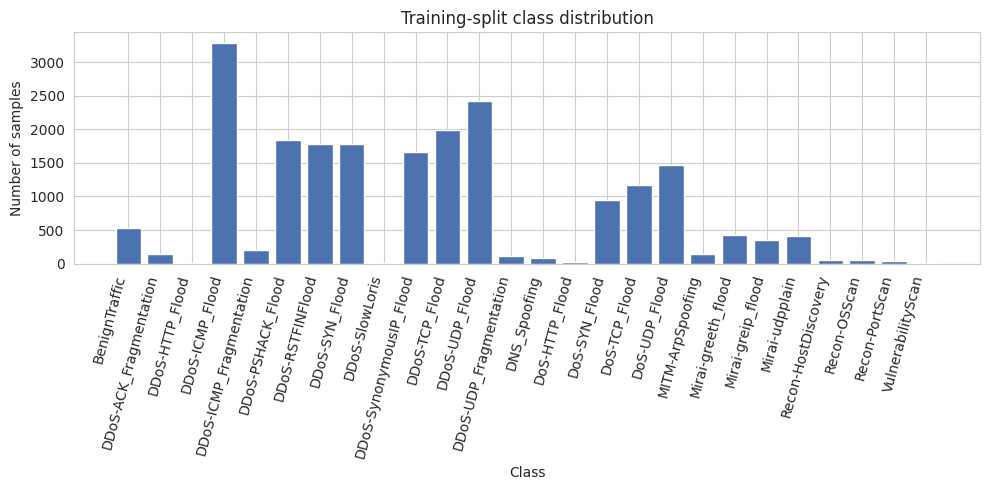

Imbalance ratio (largest class / smallest class) in TRAIN split: 273.2x
=> Meaningful class imbalance detected. Using class-weighted CrossEntropyLoss as the baseline mitigation strategy.

Per-class weights (balanced, computed on TRAIN only):
  BenignTraffic: 1.5170
  DDoS-ACK_Fragmentation: 5.3803
  DDoS-HTTP_Flood: 50.4399
  DDoS-ICMP_Flood: 0.2462
  DDoS-ICMP_Fragmentation: 3.9177
  DDoS-PSHACK_Flood: 0.4386
  DDoS-RSTFINFlood: 0.4536
  DDoS-SYN_Flood: 0.4552
  DDoS-SlowLoris: 62.0799
  DDoS-SynonymousIP_Flood: 0.4847
  DDoS-TCP_Flood: 0.4058
  DDoS-UDP_Flood: 0.3331
  DDoS-UDP_Fragmentation: 7.2706
  DNS_Spoofing: 9.1709
  DoS-HTTP_Flood: 25.2200
  DoS-SYN_Flood: 0.8468
  DoS-TCP_Flood: 0.6939
  DoS-UDP_Flood: 0.5494
  MITM-ArpSpoofing: 5.4530
  Mirai-greeth_flood: 1.8812
  Mirai-greip_flood: 2.2993
  Mirai-udpplain: 1.9494
  Recon-HostDiscovery: 14.1586
  Recon-OSScan: 16.4702
  Recon-PortScan: 18.7683
  VulnerabilityScan: 67.2532


In [84]:
fig, ax = plt.subplots(figsize=(10, 5))
train_counts = pd.Series(y_train).value_counts().sort_index()
ax.bar([class_names[i] for i in train_counts.index], train_counts.values, color="#4C72B0")
ax.set_title("Training-split class distribution")
ax.set_ylabel("Number of samples")
ax.set_xlabel("Class")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

imbalance_ratio = train_counts.max() / train_counts.min()
print(f"Imbalance ratio (largest class / smallest class) in TRAIN split: {imbalance_ratio:.1f}x")

if imbalance_ratio > 3:
    print("=> Meaningful class imbalance detected. Using class-weighted CrossEntropyLoss "
          "as the baseline mitigation strategy.")
else:
    print("=> Classes are relatively balanced in this subset; class weights will still be "
          "applied for consistency, but their effect should be mild.")

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(n_classes),
    y=y_train,
)
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float)
print("\nPer-class weights (balanced, computed on TRAIN only):")
for cname, w in zip(class_names, class_weights_array):
    print(f"  {cname}: {w:.4f}")


## 12. Graph Construction


In [85]:
def build_knn_edge_index(X: np.ndarray, k: int) -> torch.Tensor:
    """Build an undirected k-NN graph (Euclidean distance) over the rows of X.

    Returns a `edge_index` tensor of shape [2, num_edges] in PyTorch Geometric format.
    Symmetrization + de-duplication ensures the graph is undirected with no repeated edges.
    """
    n = X.shape[0]
    k_eff = min(k, n - 1)
    nbrs = NearestNeighbors(n_neighbors=k_eff + 1, algorithm="auto").fit(X)
    _, indices = nbrs.kneighbors(X)

    src_list = []
    dst_list = []
    for i in range(n):
        for j in indices[i]:
            if j == i:
                continue  # skip the self-neighbour returned by NearestNeighbors
            src_list.append(i)
            dst_list.append(j)
            src_list.append(j)  # symmetrize -> undirected graph
            dst_list.append(i)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_index = torch.unique(edge_index, dim=1)  # remove duplicate edges
    return edge_index


def make_split_graph(X: np.ndarray, y: np.ndarray, k: int) -> Data:
    edge_index = build_knn_edge_index(X, k)
    x = torch.tensor(X, dtype=torch.float)
    y_t = torch.tensor(y, dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y_t)


K_NEIGHBORS = CONFIG["k_neighbors"]
print(f"Building per-split k-NN graphs with k = {K_NEIGHBORS} "
      f"(each split's graph uses ONLY that split's own nodes -> no train/test leakage).")

t0 = time.time()
data_train = make_split_graph(X_train, y_train, K_NEIGHBORS)
data_val = make_split_graph(X_val, y_val, K_NEIGHBORS)
data_test = make_split_graph(X_test, y_test, K_NEIGHBORS)
print(f"Graph construction finished in {time.time() - t0:.1f}s")


Building per-split k-NN graphs with k = 5 (each split's graph uses ONLY that split's own nodes -> no train/test leakage).
Graph construction finished in 2.9s


## 13. Graph Statistics

--- TRAIN graph ---
  Number of nodes:    20983
  Number of edges:    136696 (directed entries; undirected pairs = 68348)
  Number of features: 46
  Number of classes:  26
  Average node degree: 6.51

--- VALIDATION graph ---
  Number of nodes:    4496
  Number of edges:    29916 (directed entries; undirected pairs = 14958)
  Number of features: 46
  Number of classes:  26
  Average node degree: 6.65

--- TEST graph ---
  Number of nodes:    4497
  Number of edges:    29992 (directed entries; undirected pairs = 14996)
  Number of features: 46
  Number of classes:  26
  Average node degree: 6.67



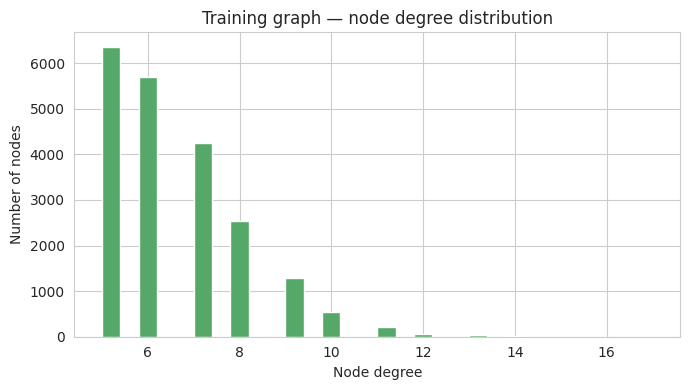

In [86]:
def print_graph_stats(data: Data, name: str):
    num_nodes = data.num_nodes
    num_edges = data.edge_index.shape[1]
    num_features = data.x.shape[1]
    avg_degree = num_edges / num_nodes if num_nodes > 0 else 0.0
    print(f"--- {name} graph ---")
    print(f"  Number of nodes:    {num_nodes}")
    print(f"  Number of edges:    {num_edges} (directed entries; undirected pairs = {num_edges // 2})")
    print(f"  Number of features: {num_features}")
    print(f"  Number of classes:  {n_classes}")
    print(f"  Average node degree: {avg_degree:.2f}")
    print()

print_graph_stats(data_train, "TRAIN")
print_graph_stats(data_val, "VALIDATION")
print_graph_stats(data_test, "TEST")

# Degree histogram for the training graph, as a sanity check on the k-NN construction
row, _ = data_train.edge_index
degrees = torch.bincount(row, minlength=data_train.num_nodes).numpy()
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(degrees, bins=30, color="#55A868")
ax.set_title("Training graph — node degree distribution")
ax.set_xlabel("Node degree")
ax.set_ylabel("Number of nodes")
plt.tight_layout()
plt.show()


## 14. Define GCN

Standard 2-layer Graph Convolutional Network (Kipf & Welling, 2017). Each `GCNConv` layer
aggregates neighbour features using the symmetrically-normalized adjacency
`D^-1/2 (A + I) D^-1/2`, which is GCN's defining characteristic.

Architecture: `Input -> GCNConv -> ReLU -> Dropout -> GCNConv -> Output`


In [87]:
class GCNBaseline(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


## 15. Define Generic GNN (plain message passing)


Architecture: `Input -> MessagePassing layer -> ReLU -> Dropout -> MessagePassing layer -> Classifier`


In [88]:
class SimpleMessagePassingLayer(MessagePassing):
    """A minimal, hand-written message-passing layer: linear transform + mean aggregation.
    No spectral (GCN-style) normalization is applied — this is what distinguishes it from GCN.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__(aggr="mean")
        self.lin = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.lin(x)
        return self.propagate(edge_index, x=x)

    def message(self, x_j):
        # x_j: features of source/neighbour nodes for each edge
        return x_j


class GenericGNN(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float):
        super().__init__()
        self.mp1 = SimpleMessagePassingLayer(in_dim, hidden_dim)
        self.mp2 = SimpleMessagePassingLayer(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.mp1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.mp2(x, edge_index)
        return x


## 16. Define GraphSAGE

Standard 2-layer GraphSAGE 

Architecture: `Input -> SAGEConv -> ReLU -> Dropout -> SAGEConv -> Classifier`


In [89]:
class GraphSAGEBaseline(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


## 17. Define PINN / Constraint-Informed GNN




In [90]:
class ConstraintInformedGNN(nn.Module):
    """Backbone is intentionally identical to GCNBaseline (2-layer GCNConv) so that any
    performance difference reflects only the added graph-smoothness constraint loss, not an
    architectural change."""
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    @staticmethod
    def smoothness_penalty(logits: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """Graph-smoothness (Dirichlet-energy-style) constraint: neighbouring nodes in the
        k-NN similarity graph should receive similar predicted class probabilities."""
        probs = F.softmax(logits, dim=1)
        row, col = edge_index
        diff = probs[row] - probs[col]
        penalty = (diff ** 2).sum(dim=1).mean()
        return penalty


## 18. Define GIN

Standard 2-layer Graph Isomorphism Network 

Architecture: `Input -> GINConv(MLP) -> ReLU -> Dropout -> GINConv(MLP) -> Classifier`


In [91]:
class GINBaseline(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float):
        super().__init__()
        mlp1 = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim)
        )
        mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, out_dim)
        )
        self.conv1 = GINConv(mlp1)
        self.conv2 = GINConv(mlp2)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


## 19. Define GAT

Standard 2-layer Graph Attention Network 

Architecture: `Input -> GATConv(heads) -> ELU -> Dropout -> GATConv(1 head) -> Classifier`


In [92]:
class GATBaseline(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float, heads: int):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_dim * heads, out_dim, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


## 20. Training Functions




In [93]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_model(model, data_train, data_val, class_weights, config, model_name,
                 use_constraint=False):
    """Train `model` on `data_train`, monitor on `data_val`, using identical hyperparameters
    for every model (see CONFIG). Returns the trained model and a per-epoch history dict."""
    model = model.to(device)
    data_train = data_train.to(device)
    data_val = data_val.to(device)
    class_weights = class_weights.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"]
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    lambda_constraint = config["lambda_constraint"]

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "epoch_time": []}

    for epoch in range(1, config["epochs"] + 1):
        t0 = time.time()

        # --- train step ---
        model.train()
        optimizer.zero_grad()
        out = model(data_train.x, data_train.edge_index)
        loss = criterion(out, data_train.y)
        if use_constraint:
            penalty = ConstraintInformedGNN.smoothness_penalty(out, data_train.edge_index)
            loss = loss + lambda_constraint * penalty
        loss.backward()
        optimizer.step()

        train_pred = out.argmax(dim=1)
        train_acc = (train_pred == data_train.y).float().mean().item()

        # --- validation step (no gradient) ---
        model.eval()
        with torch.no_grad():
            out_val = model(data_val.x, data_val.edge_index)
            val_loss = criterion(out_val, data_val.y)
            if use_constraint:
                val_penalty = ConstraintInformedGNN.smoothness_penalty(out_val, data_val.edge_index)
                val_loss = val_loss + lambda_constraint * val_penalty
            val_pred = out_val.argmax(dim=1)
            val_acc = (val_pred == data_val.y).float().mean().item()

        epoch_time = time.time() - t0
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss.item())
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        if epoch == 1 or epoch % 10 == 0 or epoch == config["epochs"]:
            print(f"[{model_name}] epoch {epoch:03d}/{config['epochs']} | "
                  f"train_loss={loss.item():.4f} val_loss={val_loss.item():.4f} | "
                  f"train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

    return model, history


## 21. Evaluation Functions




In [94]:
def evaluate_model(model, data_test, class_names, model_name):
    model.eval()
    data_test = data_test.to(device)

    t0 = time.time()
    with torch.no_grad():
        out = model(data_test.x, data_test.edge_index)
        proba = F.softmax(out, dim=1).cpu().numpy()
    inference_time = time.time() - t0

    y_true = data_test.y.cpu().numpy()
    y_pred = proba.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    try:
        n_c = len(class_names)
        if n_c > 2:
            auc = roc_auc_score(
                y_true, proba, average="macro", multi_class="ovr", labels=list(range(n_c))
            )
        else:
            auc = roc_auc_score(y_true, proba[:, 1])
    except ValueError as e:
        print(f"[{model_name}] WARNING: ROC-AUC could not be computed ({e}). Reporting NaN.")
        auc = float("nan")

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    report = classification_report(
        y_true, y_pred, labels=list(range(len(class_names))),
        target_names=[str(c) for c in class_names], zero_division=0,
    )

    metrics = {
        # unqualified Precision/Recall/F1 are reported as macro-averages, the standard
        # choice for imbalanced multiclass problems; Macro F1 and Weighted F1 are also
        # reported separately per the required results table.
        "accuracy": acc,
        "precision": precision_macro,
        "recall": recall_macro,
        "f1": f1_macro,
        "macro_f1": f1_macro,
        "weighted_f1": f1_weighted,
        "roc_auc": auc,
        "inference_time_sec": inference_time,
    }
    return metrics, y_true, y_pred, proba, cm, report


## 22–27. Train each model




In [95]:
in_dim = X_train.shape[1]
out_dim = n_classes

results_records = []
histories = {}
trained_models = {}
eval_artifacts = {}

MODELS_DIR = "/kaggle/working/models"
os.makedirs(MODELS_DIR, exist_ok=True)


def run_baseline(model_name, model_ctor, use_constraint=False):
    """Shared driver: build -> train -> evaluate -> record -> save. Identical for every model."""
    set_seed(SEED)  # reset RNG state before each model so initialization is comparable
    model = model_ctor()
    n_params = count_parameters(model)
    print(f"\n{'='*70}\nTraining {model_name}  (trainable parameters: {n_params})\n{'='*70}")

    t_start = time.time()
    trained_model, history = train_model(
        model, data_train, data_val, class_weights_tensor, CONFIG, model_name,
        use_constraint=use_constraint,
    )
    training_time = time.time() - t_start

    metrics, y_true, y_pred, proba, cm, report = evaluate_model(
        trained_model, data_test, class_names, model_name
    )

    print(f"\n[{model_name}] TEST metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
    print(f"\n[{model_name}] classification report:\n{report}")

    results_records.append({
        "model": model_name,
        "parameters": n_params,
        "num_layers": CONFIG["num_layers"],
        "hidden_dim": CONFIG["hidden_dim"],
        "learning_rate": CONFIG["learning_rate"],
        "dropout": CONFIG["dropout"],
        "epochs": CONFIG["epochs"],
        "best_val_macro_acc": max(history["val_acc"]),
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
        "roc_auc": metrics["roc_auc"],
        "training_time_sec": training_time,
        "inference_time_sec": metrics["inference_time_sec"],
    })
    histories[model_name] = history
    trained_models[model_name] = trained_model
    eval_artifacts[model_name] = {
        "y_true": y_true, "y_pred": y_pred, "proba": proba, "cm": cm, "report": report,
    }

    save_path = os.path.join(MODELS_DIR, f"{model_name.replace(' ', '_')}.pt")
    torch.save(trained_model.state_dict(), save_path)
    print(f"[{model_name}] model weights saved to {save_path}")

    return trained_model, history, metrics


## 22. Train GCN

In [96]:
_ = run_baseline(
    "GCN",
    lambda: GCNBaseline(in_dim, CONFIG["hidden_dim"], out_dim, CONFIG["dropout"]),
)



Training GCN  (trainable parameters: 4698)
[GCN] epoch 001/50 | train_loss=3.9121 val_loss=3.8986 | train_acc=0.0049 val_acc=0.0062
[GCN] epoch 010/50 | train_loss=3.3449 val_loss=3.3410 | train_acc=0.0644 val_acc=0.0647
[GCN] epoch 020/50 | train_loss=2.8977 val_loss=2.9248 | train_acc=0.2761 val_acc=0.3003
[GCN] epoch 030/50 | train_loss=2.5528 val_loss=2.6356 | train_acc=0.3182 val_acc=0.3214
[GCN] epoch 040/50 | train_loss=2.2666 val_loss=2.4105 | train_acc=0.4719 val_acc=0.5049
[GCN] epoch 050/50 | train_loss=2.0659 val_loss=2.2248 | train_acc=0.6443 val_acc=0.6559

[GCN] TEST metrics:
  accuracy: 0.6656
  precision: 0.4255
  recall: 0.4820
  f1: 0.4075
  macro_f1: 0.4075
  weighted_f1: 0.6045
  roc_auc: 0.8983
  inference_time_sec: 0.0020

[GCN] classification report:
                         precision    recall  f1-score   support

          BenignTraffic       0.68      0.59      0.63       114
 DDoS-ACK_Fragmentation       0.66      0.70      0.68        33
        DDoS-HTTP_

## 23. Train GNN (generic message passing)

In [97]:
_ = run_baseline(
    "GNN",
    lambda: GenericGNN(in_dim, CONFIG["hidden_dim"], out_dim, CONFIG["dropout"]),
)



Training GNN  (trainable parameters: 4698)
[GNN] epoch 001/50 | train_loss=3.3081 val_loss=3.2953 | train_acc=0.0365 val_acc=0.0387
[GNN] epoch 010/50 | train_loss=3.0834 val_loss=3.0831 | train_acc=0.0722 val_acc=0.0716
[GNN] epoch 020/50 | train_loss=2.8573 val_loss=2.8801 | train_acc=0.2955 val_acc=0.3381
[GNN] epoch 030/50 | train_loss=2.6405 val_loss=2.6823 | train_acc=0.4969 val_acc=0.5196
[GNN] epoch 040/50 | train_loss=2.4214 val_loss=2.4795 | train_acc=0.5872 val_acc=0.5956
[GNN] epoch 050/50 | train_loss=2.1973 val_loss=2.2740 | train_acc=0.6122 val_acc=0.6181

[GNN] TEST metrics:
  accuracy: 0.6146
  precision: 0.4145
  recall: 0.4768
  f1: 0.3729
  macro_f1: 0.3729
  weighted_f1: 0.5487
  roc_auc: 0.9314
  inference_time_sec: 0.0012

[GNN] classification report:
                         precision    recall  f1-score   support

          BenignTraffic       0.34      0.21      0.26       114
 DDoS-ACK_Fragmentation       0.75      0.27      0.40        33
        DDoS-HTTP_

## 24. Train GraphSAGE

In [98]:
_ = run_baseline(
    "GraphSAGE",
    lambda: GraphSAGEBaseline(in_dim, CONFIG["hidden_dim"], out_dim, CONFIG["dropout"]),
)



Training GraphSAGE  (trainable parameters: 9306)
[GraphSAGE] epoch 001/50 | train_loss=3.3457 val_loss=3.2468 | train_acc=0.0356 val_acc=0.0981
[GraphSAGE] epoch 010/50 | train_loss=2.7641 val_loss=2.7361 | train_acc=0.2411 val_acc=0.3521
[GraphSAGE] epoch 020/50 | train_loss=2.3162 val_loss=2.3208 | train_acc=0.4736 val_acc=0.5478
[GraphSAGE] epoch 030/50 | train_loss=1.9515 val_loss=1.9918 | train_acc=0.5727 val_acc=0.5974
[GraphSAGE] epoch 040/50 | train_loss=1.6564 val_loss=1.7274 | train_acc=0.6104 val_acc=0.6199
[GraphSAGE] epoch 050/50 | train_loss=1.4364 val_loss=1.5195 | train_acc=0.6295 val_acc=0.6232

[GraphSAGE] TEST metrics:
  accuracy: 0.6209
  precision: 0.4827
  recall: 0.5690
  f1: 0.4644
  macro_f1: 0.4644
  weighted_f1: 0.5628
  roc_auc: 0.9564
  inference_time_sec: 0.0011

[GraphSAGE] classification report:
                         precision    recall  f1-score   support

          BenignTraffic       0.89      0.42      0.57       114
 DDoS-ACK_Fragmentation      

## 25. Train PINN (constraint-informed GNN)

In [99]:
_ = run_baseline(
    "PINN",
    lambda: ConstraintInformedGNN(in_dim, CONFIG["hidden_dim"], out_dim, CONFIG["dropout"]),
    use_constraint=True,
)



Training PINN  (trainable parameters: 4698)
[PINN] epoch 001/50 | train_loss=3.9124 val_loss=3.8989 | train_acc=0.0049 val_acc=0.0062
[PINN] epoch 010/50 | train_loss=3.3451 val_loss=3.3412 | train_acc=0.0644 val_acc=0.0649
[PINN] epoch 020/50 | train_loss=2.8979 val_loss=2.9250 | train_acc=0.2761 val_acc=0.3003
[PINN] epoch 030/50 | train_loss=2.5531 val_loss=2.6358 | train_acc=0.3182 val_acc=0.3214
[PINN] epoch 040/50 | train_loss=2.2670 val_loss=2.4107 | train_acc=0.4720 val_acc=0.5051
[PINN] epoch 050/50 | train_loss=2.0663 val_loss=2.2250 | train_acc=0.6444 val_acc=0.6559

[PINN] TEST metrics:
  accuracy: 0.6651
  precision: 0.4245
  recall: 0.4813
  f1: 0.4068
  macro_f1: 0.4068
  weighted_f1: 0.6041
  roc_auc: 0.8983
  inference_time_sec: 0.0017

[PINN] classification report:
                         precision    recall  f1-score   support

          BenignTraffic       0.68      0.57      0.62       114
 DDoS-ACK_Fragmentation       0.66      0.70      0.68        33
        D

## 26. Train GIN

In [100]:
_ = run_baseline(
    "GIN",
    lambda: GINBaseline(in_dim, CONFIG["hidden_dim"], out_dim, CONFIG["dropout"]),
)



Training GIN  (trainable parameters: 13018)
[GIN] epoch 001/50 | train_loss=6.9148 val_loss=5.8769 | train_acc=0.0234 val_acc=0.0227
[GIN] epoch 010/50 | train_loss=2.5709 val_loss=2.6758 | train_acc=0.4313 val_acc=0.4833
[GIN] epoch 020/50 | train_loss=1.6174 val_loss=1.6921 | train_acc=0.5792 val_acc=0.5907
[GIN] epoch 030/50 | train_loss=1.1321 val_loss=1.3157 | train_acc=0.6936 val_acc=0.7378
[GIN] epoch 040/50 | train_loss=0.9267 val_loss=1.1845 | train_acc=0.7046 val_acc=0.7046
[GIN] epoch 050/50 | train_loss=0.8130 val_loss=1.1481 | train_acc=0.7273 val_acc=0.7482

[GIN] TEST metrics:
  accuracy: 0.7441
  precision: 0.5500
  recall: 0.5871
  f1: 0.5494
  macro_f1: 0.5494
  weighted_f1: 0.7328
  roc_auc: 0.9799
  inference_time_sec: 0.0011

[GIN] classification report:
                         precision    recall  f1-score   support

          BenignTraffic       0.64      0.60      0.62       114
 DDoS-ACK_Fragmentation       0.97      0.97      0.97        33
        DDoS-HTTP

## 27. Train GAT

In [101]:
_ = run_baseline(
    "GAT",
    lambda: GATBaseline(in_dim, CONFIG["hidden_dim"], out_dim, CONFIG["dropout"], CONFIG["gat_heads"]),
)



Training GAT  (trainable parameters: 19278)
[GAT] epoch 001/50 | train_loss=3.9205 val_loss=3.4000 | train_acc=0.0411 val_acc=0.1128
[GAT] epoch 010/50 | train_loss=2.4163 val_loss=2.4100 | train_acc=0.5103 val_acc=0.6428
[GAT] epoch 020/50 | train_loss=1.8287 val_loss=1.8768 | train_acc=0.6593 val_acc=0.6733
[GAT] epoch 030/50 | train_loss=1.5167 val_loss=1.5841 | train_acc=0.6935 val_acc=0.7200
[GAT] epoch 040/50 | train_loss=1.3158 val_loss=1.3990 | train_acc=0.7080 val_acc=0.7531
[GAT] epoch 050/50 | train_loss=1.1761 val_loss=1.2802 | train_acc=0.7041 val_acc=0.7244

[GAT] TEST metrics:
  accuracy: 0.7220
  precision: 0.5552
  recall: 0.6104
  f1: 0.5524
  macro_f1: 0.5524
  weighted_f1: 0.7090
  roc_auc: 0.9674
  inference_time_sec: 0.0033

[GAT] classification report:
                         precision    recall  f1-score   support

          BenignTraffic       0.82      0.39      0.53       114
 DDoS-ACK_Fragmentation       0.97      0.94      0.95        33
        DDoS-HTTP

## 28. Baseline Comparison




In [102]:
results_df = pd.DataFrame(results_records)
results_df_sorted = results_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)

display_cols = [
    "model", "parameters", "accuracy", "precision", "recall", "f1",
    "macro_f1", "weighted_f1", "roc_auc", "training_time_sec", "inference_time_sec",
]
print("Baseline comparison (sorted by Macro F1, descending):\n")
results_df_sorted[display_cols].round(4)


Baseline comparison (sorted by Macro F1, descending):



,model,parameters,accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,training_time_sec,inference_time_sec
0,GAT,19278,0.7220,0.5552,0.6104,0.5524,0.5524,0.7090,0.9674,1.1645,0.0033
1,GIN,13018,0.7441,0.5500,0.5871,0.5494,0.5494,0.7328,0.9799,0.2915,0.0011
2,GraphSAGE,9306,0.6209,0.4827,0.5690,0.4644,0.4644,0.5628,0.9564,0.2629,0.0011
3,GCN,4698,0.6656,0.4255,0.4820,0.4075,0.4075,0.6045,0.8983,0.4405,0.0020
4,PINN,4698,0.6651,0.4245,0.4813,0.4068,0.4068,0.6041,0.8983,0.4796,0.0017
5,GNN,4698,0.6146,0.4145,0.4768,0.3729,0.3729,0.5487,0.9314,0.2343,0.0012


## 29. Confusion Matrix — Best Baseline Model

Best baseline model by Macro F1: GAT


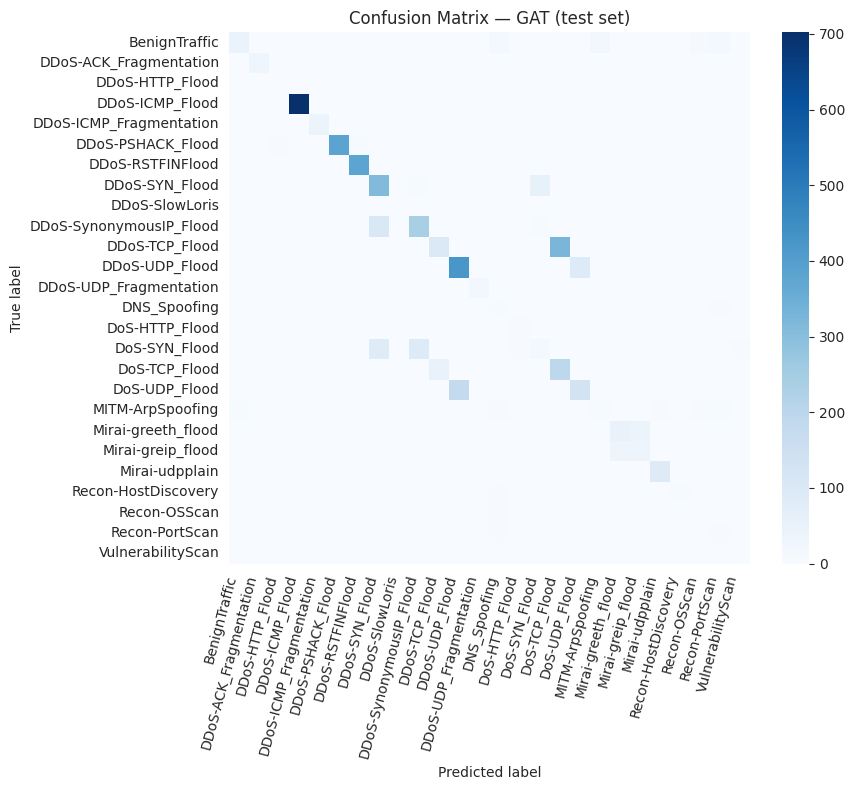

In [103]:
best_model_name = results_df_sorted.iloc[0]["model"]
print(f"Best baseline model by Macro F1: {best_model_name}")

cm_best = eval_artifacts[best_model_name]["cm"]
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    cm_best, annot=(len(class_names) <= 15), fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=True,
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Confusion Matrix — {best_model_name} (test set)")
plt.xticks(rotation=75, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 30. Training Curves

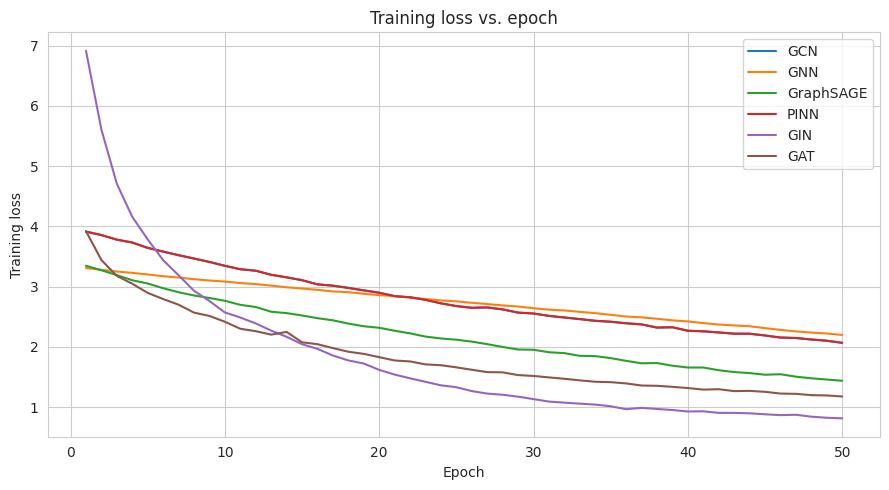

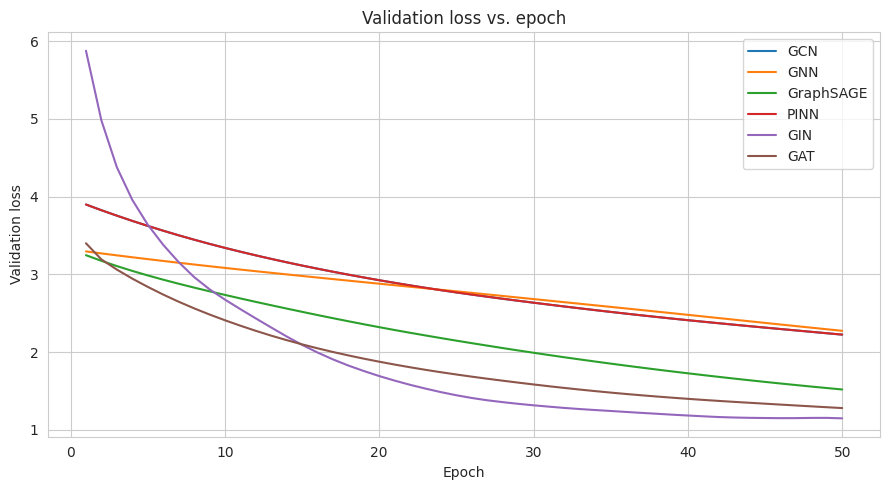

In [104]:
# --- Plot 1: training loss vs epoch, all models ---
fig, ax = plt.subplots(figsize=(9, 5))
for name, h in histories.items():
    ax.plot(range(1, len(h["train_loss"]) + 1), h["train_loss"], label=name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.set_title("Training loss vs. epoch")
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: validation loss vs epoch, all models ---
fig, ax = plt.subplots(figsize=(9, 5))
for name, h in histories.items():
    ax.plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], label=name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation loss")
ax.set_title("Validation loss vs. epoch")
ax.legend()
plt.tight_layout()
plt.show()


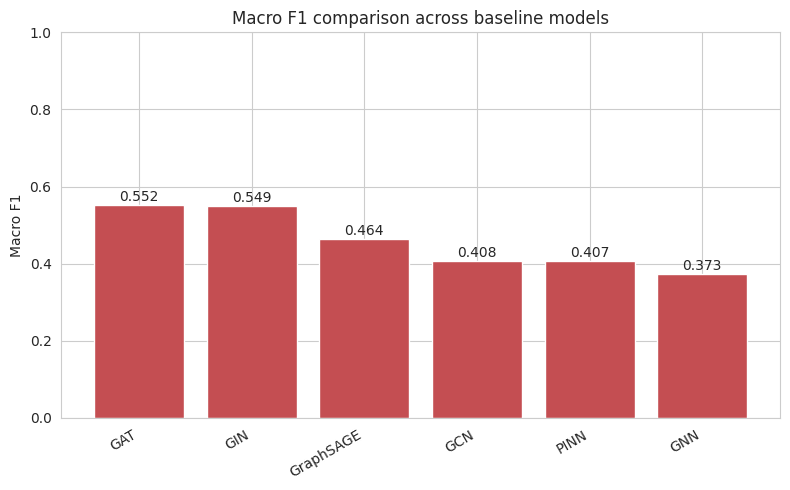

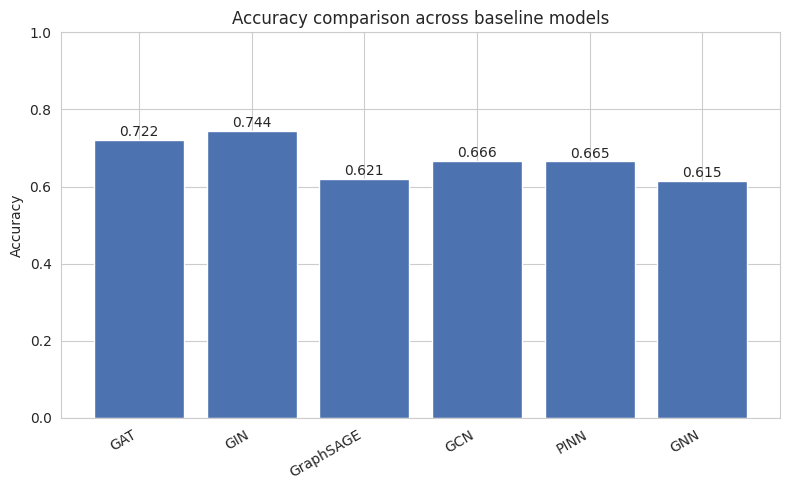

In [105]:
# --- Plot 3: Macro F1 comparison ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(results_df_sorted["model"], results_df_sorted["macro_f1"], color="#C44E52")
ax.set_ylabel("Macro F1")
ax.set_title("Macro F1 comparison across baseline models")
ax.set_ylim(0, 1.0)
for i, v in enumerate(results_df_sorted["macro_f1"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# --- Plot 4: Accuracy comparison ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(results_df_sorted["model"], results_df_sorted["accuracy"], color="#4C72B0")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy comparison across baseline models")
ax.set_ylim(0, 1.0)
for i, v in enumerate(results_df_sorted["accuracy"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 31. Final Results Table

In [106]:
final_table = results_df_sorted[display_cols].round(4)
final_table.columns = [
    "Model", "Parameters", "Accuracy", "Precision", "Recall", "F1",
    "Macro F1", "Weighted F1", "AUC", "Training Time (s)", "Inference Time (s)",
]
final_table


,Model,Parameters,Accuracy,Precision,Recall,F1,Macro F1,Weighted F1,AUC,Training Time (s),Inference Time (s)
0,GAT,19278,0.7220,0.5552,0.6104,0.5524,0.5524,0.7090,0.9674,1.1645,0.0033
1,GIN,13018,0.7441,0.5500,0.5871,0.5494,0.5494,0.7328,0.9799,0.2915,0.0011
2,GraphSAGE,9306,0.6209,0.4827,0.5690,0.4644,0.4644,0.5628,0.9564,0.2629,0.0011
3,GCN,4698,0.6656,0.4255,0.4820,0.4075,0.4075,0.6045,0.8983,0.4405,0.0020
4,PINN,4698,0.6651,0.4245,0.4813,0.4068,0.4068,0.6041,0.8983,0.4796,0.0017
5,GNN,4698,0.6146,0.4145,0.4768,0.3729,0.3729,0.5487,0.9314,0.2343,0.0012


## 32. Save Results

In [107]:
RESULTS_PATH = "/kaggle/working/baseline_results.csv"
results_df_sorted.to_csv(RESULTS_PATH, index=False)
print(f"Saved baseline results table to: {RESULTS_PATH}")

CONFIG_PATH = "/kaggle/working/baseline_config.json"
with open(CONFIG_PATH, "w") as f:
    json.dump(CONFIG, f, indent=2)
print(f"Saved experiment configuration to: {CONFIG_PATH}")

print(f"\nTrained model weights saved under: {MODELS_DIR}")
for fname in sorted(os.listdir(MODELS_DIR)):
    print(f"  {fname}")


Saved baseline results table to: /kaggle/working/baseline_results.csv
Saved experiment configuration to: /kaggle/working/baseline_config.json

Trained model weights saved under: /kaggle/working/models
  GAT.pt
  GCN.pt
  GIN.pt
  GNN.pt
  GraphSAGE.pt
  PINN.pt
